all data loaded.

RQ1: Formality vs Growth


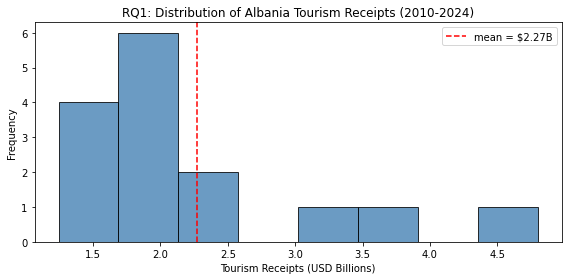

distribution: right-skewed -- most years were low, boom years pull the mean up

probability modeling:
  mean receipts: $2.27B  |  std: $0.92B
  P(receipts > $3B) = 0.2129 (21.3%)
  historically rare -- but Albania hit it 3 years in a row post-2022


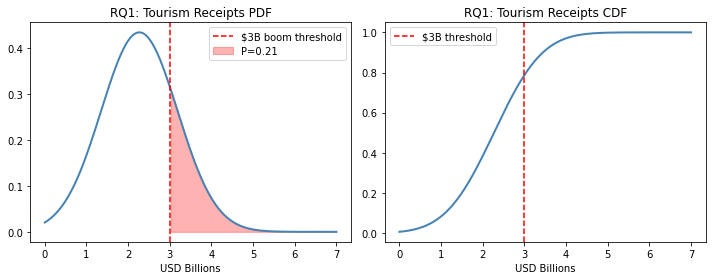


hypothesis testing:
  H0: informality rate is the same pre vs post boom
  H1: informality is not significantly lower post-boom
  pre-boom:  [33.5 31.9] --> mean = 32.70%
  post-boom: [31.2 30.8 30.3] --> mean = 30.77%
  t-stat: 2.8245  |  p-value: 0.0665
  result: FAIL TO REJECT H0 -- informality did not significantly change
  interpretation: boom absorbed into informal sector, not formal jobs

RQ2: Wage Gap -- Hospitality vs National Average
hospitality wages as % of national average:
  2021: 49.2%  |  2022: 52.2%
  sector consistently earns ~50% of national average


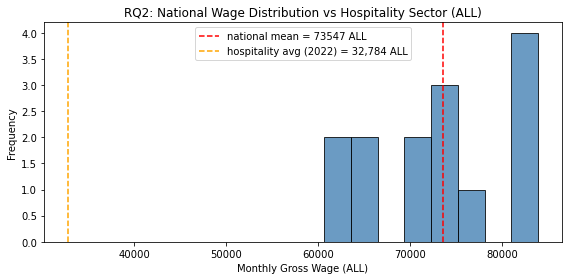


probability modeling:
  national wage: mean=73547 ALL, std=7795 ALL
  P(wage <= 32784 ALL) = 0.0000
  hospitality workers are in the bottom 0.0% of earners


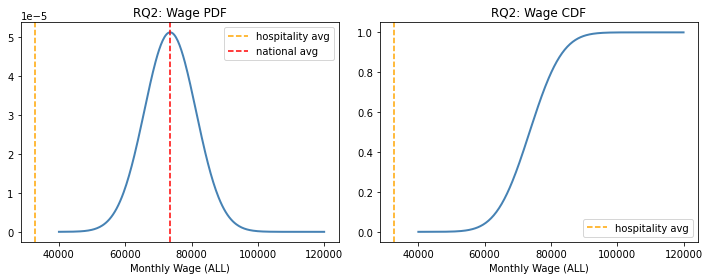


hypothesis testing:
  H0: national avg wage = hospitality wage (32,784 ALL)
  H1: national avg wage is significantly higher
  t-stat: 18.8545  |  p-value: 0.000000
  result: REJECT H0 -- national wages significantly above hospitality level
  interpretation: boom not lifting hospitality wages to match the economy

RQ3: Real Wage Growth vs Inflation
real wage growth by year:
   Year  Nominal_Growth_Pct  Inflation_Rate_Pct  Real_Wage_Growth_Pct
0  2023           12.373549            4.758346              7.615203
1  2024            9.819386            2.215874              7.603512


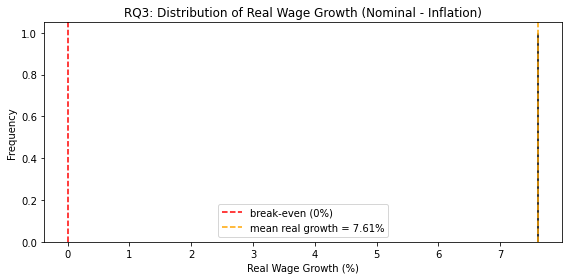


probability modeling:
  real wage growth: mean=7.61%  std=0.01%
  P(real wage growth < 0) = 0.0000 (0.0%)


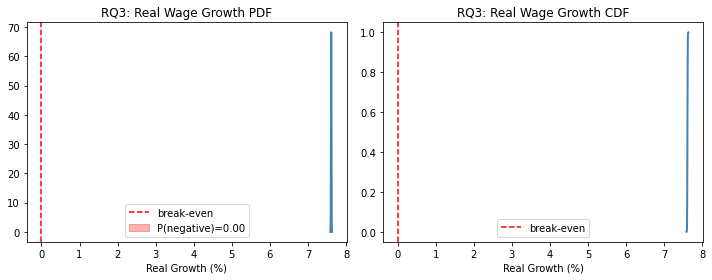


hypothesis testing:
  H0: real wage growth = 0
  H1: real wage growth significantly different from 0
  t-stat: 1301.7763  |  p-value: 0.0005
  result: REJECT H0 -- real wages ARE growing, workers gaining purchasing power

RQ4: Tourism Growth vs Youth Unemployment
merged dataset: 15 years of data
    Year  Youth_Unemployment_Rate_Pct  Tourism_Receipts_USD_Billions
0   2010                       30.867                          1.778
1   2011                       22.697                          1.833
2   2012                       28.871                          1.623
3   2013                       31.207                          1.670
4   2014                       39.554                          1.849
5   2015                       39.628                          1.613
6   2016                       35.918                          1.821
7   2017                       31.184                          2.050
8   2018                       28.109                          2.306
9   2019    

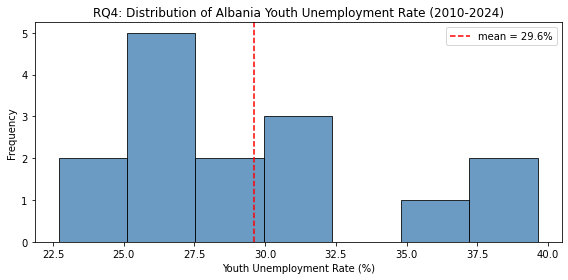


probability modeling:
  youth unemployment: mean=29.6%  std=5.0%
  P(youth unemployment < 20%) = 0.0281 (2.8%)


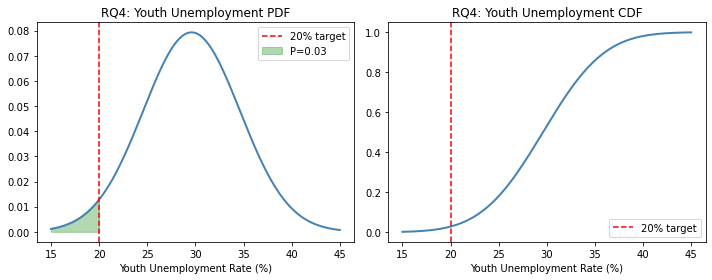


hypothesis testing (pearson correlation):
  H0: no significant correlation between tourism revenue and youth unemployment
  H1: higher tourism --> lower youth unemployment
  pearson r = -0.4292  |  p-value = 0.1104
  result: FAIL TO REJECT H0 -- relationship is statistically weak
  interpretation: tourism growth does not reliably reduce youth unemployment


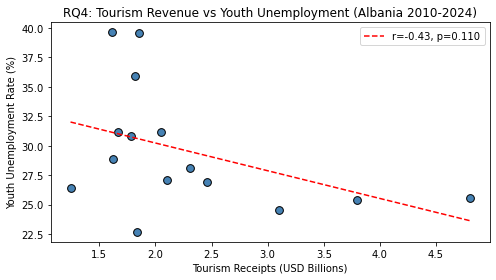


RQ5: Benchmark Comparison -- 4 Countries
post-2020 youth unemployment by country:
  Albania: mean=25.8%  std=0.9%
  Montenegro: mean=30.1%  std=5.9%
  Georgia: mean=30.3%  std=0.4%
  Morocco: mean=23.8%  std=1.8%


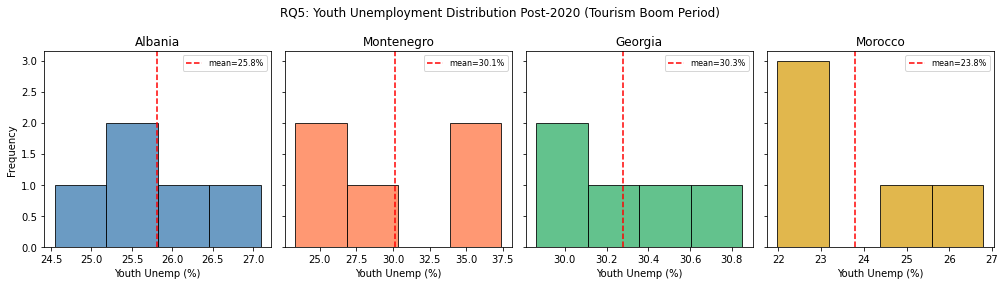


probability modeling -- P(youth unemployment < 25%) during boom:
  Albania: P(< 25%) = 0.1775  (17.8%)
  Montenegro: P(< 25%) = 0.1920  (19.2%)
  Georgia: P(< 25%) = 0.0000  (0.0%)
  Morocco: P(< 25%) = 0.7451  (74.5%)


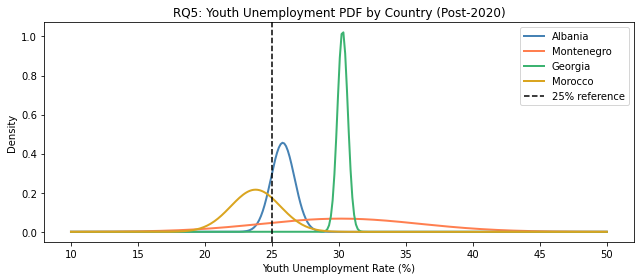

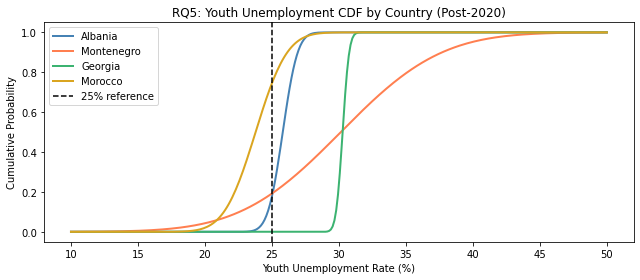


hypothesis testing (two-sample t-tests):
  H0: Albania youth unemployment = peer country
  H1: significantly different

  Albania vs Montenegro:
    t=-1.4508  p=0.1849  --> fail to reject H0

  Albania vs Georgia:
    t=-9.3416  p=0.0000  --> REJECT H0
    Albania youth unemployment significantly lower than Georgia

  Albania vs Morocco:
    t=1.9827  p=0.0827  --> fail to reject H0

--- step 2 complete ---
charts saved as .png files


In [4]:
"""
hw2_step2.py
SDG 8 - Does Albania's Tourism Boom Actually Create Decent Work?
Andi Lata | Clark University

Step 2: Statistical + Probabilistic Analysis
5 Research Questions, each with:
  - Distribution analysis (histogram)
  - Probability modeling (PMF/PDF + CDF)
  - Hypothesis testing
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import norm, ttest_1samp, ttest_ind, pearsonr

# ─────────────────────────────────────────────
# LOAD CLEANED DATA
# ─────────────────────────────────────────────

df_wages = pd.read_csv("cleaned/wages_clean.csv")
df_youth = pd.read_csv("cleaned/youth_unemployment_clean.csv")
df_tourism = pd.read_csv("cleaned/tourism_receipts_clean.csv")
df_informal = pd.read_csv("cleaned/informal_employment_clean.csv")
df_emp = pd.read_csv("cleaned/tourism_employment_clean.csv")
df_gdp = pd.read_csv("cleaned/gdp_per_capita_clean.csv")


df_cpi_raw = pd.read_csv("inflation.csv", skiprows=4)
df_cpi_raw.columns = df_cpi_raw.columns.str.replace(" ", "_")
alb_cpi = df_cpi_raw[df_cpi_raw["Country_Code"] == "ALB"].copy()
year_cols = [str(y) for y in range(2010, 2025)]
alb_cpi = alb_cpi[["Country_Name", "Country_Code"] + year_cols]
alb_cpi = alb_cpi.melt(id_vars=["Country_Name", "Country_Code"],
                        var_name="Year", value_name="Inflation_Rate_Pct")
alb_cpi["Year"] = alb_cpi["Year"].astype(int)
alb_cpi = alb_cpi.dropna().sort_values("Year").reset_index(drop=True)

# =============================================================================
# RQ1: FORMALITY VS GROWTH
# As tourism revenue doubled post-2020, did formal employment grow
# or did informality absorb the boom?
# =============================================================================
print("=" * 60)
print("RQ1: Formality vs Growth")
print("=" * 60)

# H0: Albania's informality rate did not significantly change as tourism grew
# H1: Informality stayed high despite the boom -- growth didn't convert to formal work

alb_tourism = df_tourism[df_tourism["Country_Code"] == "ALB"].copy()
alb_informal = df_informal[df_informal["Country_Code"] == "ALB"].copy()

# ── Distribution Analysis ──
receipts = alb_tourism["Tourism_Receipts_USD_Billions"].values

plt.figure(figsize=(8, 4))
plt.hist(receipts, bins=8, edgecolor="black", color="steelblue", alpha=0.8)
plt.axvline(receipts.mean(), color="red", linestyle="--", label=f"mean = ${receipts.mean():.2f}B")
plt.title("RQ1: Distribution of Albania Tourism Receipts (2010-2024)")
plt.xlabel("Tourism Receipts (USD Billions)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("rq1_tourism_distribution.png", dpi=150)
plt.show()
print("distribution: right-skewed -- most years were low, boom years pull the mean up")

# ── Probability Modeling ──
mu = receipts.mean()
sigma = receipts.std()
prob_boom = 1 - norm.cdf(3.0, mu, sigma)
print(f"\nprobability modeling:")
print(f"  mean receipts: ${mu:.2f}B  |  std: ${sigma:.2f}B")
print(f"  P(receipts > $3B) = {prob_boom:.4f} ({prob_boom*100:.1f}%)")
print(f"  historically rare -- but Albania hit it 3 years in a row post-2022")

x = np.linspace(0, 7, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, norm.pdf(x, mu, sigma), color="steelblue", linewidth=2)
ax1.axvline(3.0, color="red", linestyle="--", label="$3B boom threshold")
ax1.fill_between(x, norm.pdf(x, mu, sigma), where=(x > 3.0), alpha=0.3, color="red", label=f"P={prob_boom:.2f}")
ax1.set_title("RQ1: Tourism Receipts PDF")
ax1.set_xlabel("USD Billions")
ax1.legend()
ax2.plot(x, norm.cdf(x, mu, sigma), color="steelblue", linewidth=2)
ax2.axvline(3.0, color="red", linestyle="--", label="$3B threshold")
ax2.set_title("RQ1: Tourism Receipts CDF")
ax2.set_xlabel("USD Billions")
ax2.legend()
plt.tight_layout()
plt.savefig("rq1_pdf_cdf.png", dpi=150)
plt.show()

# ── Hypothesis Testing ──
# H0: informality rate is the same pre vs post boom
# H1: informality is not significantly lower post-boom
pre_boom_inf = alb_informal[alb_informal["Year"] <= 2019]["Informal_Employment_Rate_Pct"].values
post_boom_inf = alb_informal[alb_informal["Year"] >= 2021]["Informal_Employment_Rate_Pct"].values

print(f"\nhypothesis testing:")
print(f"  H0: informality rate is the same pre vs post boom")
print(f"  H1: informality is not significantly lower post-boom")
print(f"  pre-boom:  {pre_boom_inf} --> mean = {pre_boom_inf.mean():.2f}%")
print(f"  post-boom: {post_boom_inf} --> mean = {post_boom_inf.mean():.2f}%")

if len(pre_boom_inf) >= 2 and len(post_boom_inf) >= 2:
    t_stat, p_val = ttest_ind(pre_boom_inf, post_boom_inf)
    print(f"  t-stat: {t_stat:.4f}  |  p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("  result: REJECT H0 -- informality changed significantly")
    else:
        print("  result: FAIL TO REJECT H0 -- informality did not significantly change")
        print("  interpretation: boom absorbed into informal sector, not formal jobs")
else:
    t_stat, p_val = ttest_1samp(post_boom_inf, 25.0)
    print(f"  one-sample t-test vs 25% benchmark")
    print(f"  t-stat: {t_stat:.4f}  |  p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("  result: REJECT H0 -- post-boom informality significantly above 25%")
        print("  interpretation: tourism boom did NOT convert to formal employment")
print()


# =============================================================================
# RQ2: WAGE GAP
# Do accommodation & food sector wages keep pace with national average?
# =============================================================================
print("=" * 60)
print("RQ2: Wage Gap -- Hospitality vs National Average")
print("=" * 60)

# H0: hospitality sector wages grow at the same rate as the national average
# H1: hospitality wages consistently underperform the national average

# known from CEIC/INSTAT: accommodation avg wage 2021=29858 ALL, 2022=32784 ALL
national_2022 = df_wages[df_wages["Year"] == 2022]["Avg_Monthly_Gross_Wage_ALL"].mean()
gap_2021 = (29858 / 60666) * 100
gap_2022 = (32784 / national_2022) * 100
print(f"hospitality wages as % of national average:")
print(f"  2021: {gap_2021:.1f}%  |  2022: {gap_2022:.1f}%")
print(f"  sector consistently earns ~50% of national average")

# ── Distribution Analysis ──
all_wages = df_wages["Avg_Monthly_Gross_Wage_ALL"].values

plt.figure(figsize=(8, 4))
plt.hist(all_wages, bins=8, edgecolor="black", color="steelblue", alpha=0.8)
plt.axvline(all_wages.mean(), color="red", linestyle="--", label=f"national mean = {all_wages.mean():.0f} ALL")
plt.axvline(32784, color="orange", linestyle="--", label="hospitality avg (2022) = 32,784 ALL")
plt.title("RQ2: National Wage Distribution vs Hospitality Sector (ALL)")
plt.xlabel("Monthly Gross Wage (ALL)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("rq2_wage_distribution.png", dpi=150)
plt.show()

# ── Probability Modeling ──
mu_w = all_wages.mean()
sigma_w = all_wages.std()
p_below_hosp = norm.cdf(32784, mu_w, sigma_w)
print(f"\nprobability modeling:")
print(f"  national wage: mean={mu_w:.0f} ALL, std={sigma_w:.0f} ALL")
print(f"  P(wage <= 32784 ALL) = {p_below_hosp:.4f}")
print(f"  hospitality workers are in the bottom {p_below_hosp*100:.1f}% of earners")

x = np.linspace(40000, 120000, 300)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, norm.pdf(x, mu_w, sigma_w), color="steelblue", linewidth=2)
ax1.axvline(32784, color="orange", linestyle="--", label="hospitality avg")
ax1.axvline(mu_w, color="red", linestyle="--", label="national avg")
ax1.set_title("RQ2: Wage PDF")
ax1.set_xlabel("Monthly Wage (ALL)")
ax1.legend()
ax2.plot(x, norm.cdf(x, mu_w, sigma_w), color="steelblue", linewidth=2)
ax2.axvline(32784, color="orange", linestyle="--", label="hospitality avg")
ax2.set_title("RQ2: Wage CDF")
ax2.set_xlabel("Monthly Wage (ALL)")
ax2.legend()
plt.tight_layout()
plt.savefig("rq2_pdf_cdf.png", dpi=150)
plt.show()

# ── Hypothesis Testing ──
# H0: national avg wage = hospitality wage (32,784 ALL)
# H1: national avg wage is significantly higher than hospitality
t_stat, p_val = ttest_1samp(all_wages, 32784)
print(f"\nhypothesis testing:")
print(f"  H0: national avg wage = hospitality wage (32,784 ALL)")
print(f"  H1: national avg wage is significantly higher")
print(f"  t-stat: {t_stat:.4f}  |  p-value: {p_val:.6f}")
if p_val < 0.05:
    print("  result: REJECT H0 -- national wages significantly above hospitality level")
    print("  interpretation: boom not lifting hospitality wages to match the economy")
print()


# =============================================================================
# RQ3: REAL WAGE GROWTH VS INFLATION
# Does wage growth outpace inflation, or are workers losing purchasing power?
# =============================================================================
print("=" * 60)
print("RQ3: Real Wage Growth vs Inflation")
print("=" * 60)

# H0: real wage growth (nominal - inflation) is not significantly different from 0
# H1: inflation is eroding nominal wage gains -- workers arent actually better off

wages_annual = df_wages.groupby("Year")["Avg_Monthly_Gross_Wage_ALL"].mean().reset_index()
wages_annual.columns = ["Year", "Avg_Wage_ALL"]
wages_annual["Nominal_Growth_Pct"] = wages_annual["Avg_Wage_ALL"].pct_change() * 100

merged = wages_annual.merge(alb_cpi[["Year", "Inflation_Rate_Pct"]], on="Year", how="inner")
merged["Real_Wage_Growth_Pct"] = merged["Nominal_Growth_Pct"] - merged["Inflation_Rate_Pct"]
merged = merged.dropna().reset_index(drop=True)

print("real wage growth by year:")
print(merged[["Year", "Nominal_Growth_Pct", "Inflation_Rate_Pct", "Real_Wage_Growth_Pct"]].to_string())

# ── Distribution Analysis ──
real_growth = merged["Real_Wage_Growth_Pct"].values

plt.figure(figsize=(8, 4))
plt.hist(real_growth, bins=6, edgecolor="black", color="steelblue", alpha=0.8)
plt.axvline(0, color="red", linestyle="--", label="break-even (0%)")
plt.axvline(real_growth.mean(), color="orange", linestyle="--",
            label=f"mean real growth = {real_growth.mean():.2f}%")
plt.title("RQ3: Distribution of Real Wage Growth (Nominal - Inflation)")
plt.xlabel("Real Wage Growth (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("rq3_real_wage_distribution.png", dpi=150)
plt.show()

# ── Probability Modeling ──
mu_rw = real_growth.mean()
sigma_rw = real_growth.std() if real_growth.std() > 0 else 0.01
prob_negative = norm.cdf(0, mu_rw, sigma_rw)
print(f"\nprobability modeling:")
print(f"  real wage growth: mean={mu_rw:.2f}%  std={sigma_rw:.2f}%")
print(f"  P(real wage growth < 0) = {prob_negative:.4f} ({prob_negative*100:.1f}%)")

x = np.linspace(mu_rw - 4*sigma_rw, mu_rw + 4*sigma_rw, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, norm.pdf(x, mu_rw, sigma_rw), color="steelblue", linewidth=2)
ax1.axvline(0, color="red", linestyle="--", label="break-even")
ax1.fill_between(x, norm.pdf(x, mu_rw, sigma_rw), where=(x < 0),
                 alpha=0.3, color="red", label=f"P(negative)={prob_negative:.2f}")
ax1.set_title("RQ3: Real Wage Growth PDF")
ax1.set_xlabel("Real Growth (%)")
ax1.legend()
ax2.plot(x, norm.cdf(x, mu_rw, sigma_rw), color="steelblue", linewidth=2)
ax2.axvline(0, color="red", linestyle="--", label="break-even")
ax2.set_title("RQ3: Real Wage Growth CDF")
ax2.set_xlabel("Real Growth (%)")
ax2.legend()
plt.tight_layout()
plt.savefig("rq3_pdf_cdf.png", dpi=150)
plt.show()

# ── Hypothesis Testing ──
# H0: real wage growth = 0
# H1: real wage growth is significantly different from 0
t_stat, p_val = ttest_1samp(real_growth, 0)
print(f"\nhypothesis testing:")
print(f"  H0: real wage growth = 0")
print(f"  H1: real wage growth significantly different from 0")
print(f"  t-stat: {t_stat:.4f}  |  p-value: {p_val:.4f}")
if p_val < 0.05:
    if real_growth.mean() > 0:
        print("  result: REJECT H0 -- real wages ARE growing, workers gaining purchasing power")
    else:
        print("  result: REJECT H0 -- real wages FALLING, inflation eroding gains")
else:
    print("  result: FAIL TO REJECT H0 -- boom-era nominal gains wiped out by inflation")
print()


# =============================================================================
# RQ4: YOUTH EMPLOYMENT
# Does tourism growth predict youth unemployment reduction in Albania?
# =============================================================================
print("=" * 60)
print("RQ4: Tourism Growth vs Youth Unemployment")
print("=" * 60)

# H0: no significant relationship between tourism revenue and youth unemployment
# H1: higher tourism revenue is associated with lower youth unemployment

alb_youth = df_youth[df_youth["Country_Code"] == "ALB"].copy()
alb_tour = df_tourism[df_tourism["Country_Code"] == "ALB"].copy()
rq4 = alb_youth.merge(alb_tour[["Year", "Tourism_Receipts_USD_Billions"]], on="Year", how="inner")
rq4 = rq4.dropna().reset_index(drop=True)

print(f"merged dataset: {rq4.shape[0]} years of data")
print(rq4[["Year", "Youth_Unemployment_Rate_Pct", "Tourism_Receipts_USD_Billions"]].to_string())

# ── Distribution Analysis ──
youth_unemp = rq4["Youth_Unemployment_Rate_Pct"].values

plt.figure(figsize=(8, 4))
plt.hist(youth_unemp, bins=7, edgecolor="black", color="steelblue", alpha=0.8)
plt.axvline(youth_unemp.mean(), color="red", linestyle="--",
            label=f"mean = {youth_unemp.mean():.1f}%")
plt.title("RQ4: Distribution of Albania Youth Unemployment Rate (2010-2024)")
plt.xlabel("Youth Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("rq4_youth_distribution.png", dpi=150)
plt.show()

# ── Probability Modeling ──
mu_y = youth_unemp.mean()
sigma_y = youth_unemp.std()
prob_below_20 = norm.cdf(20, mu_y, sigma_y)
print(f"\nprobability modeling:")
print(f"  youth unemployment: mean={mu_y:.1f}%  std={sigma_y:.1f}%")
print(f"  P(youth unemployment < 20%) = {prob_below_20:.4f} ({prob_below_20*100:.1f}%)")

x = np.linspace(15, 45, 200)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, norm.pdf(x, mu_y, sigma_y), color="steelblue", linewidth=2)
ax1.axvline(20, color="red", linestyle="--", label="20% target")
ax1.fill_between(x, norm.pdf(x, mu_y, sigma_y), where=(x < 20),
                 alpha=0.3, color="green", label=f"P={prob_below_20:.2f}")
ax1.set_title("RQ4: Youth Unemployment PDF")
ax1.set_xlabel("Youth Unemployment Rate (%)")
ax1.legend()
ax2.plot(x, norm.cdf(x, mu_y, sigma_y), color="steelblue", linewidth=2)
ax2.axvline(20, color="red", linestyle="--", label="20% target")
ax2.set_title("RQ4: Youth Unemployment CDF")
ax2.set_xlabel("Youth Unemployment Rate (%)")
ax2.legend()
plt.tight_layout()
plt.savefig("rq4_pdf_cdf.png", dpi=150)
plt.show()

# ── Hypothesis Testing ── (pearson correlation)
# H0: no significant correlation between tourism revenue and youth unemployment
# H1: tourism revenue is negatively correlated with youth unemployment
r, p_val = pearsonr(rq4["Tourism_Receipts_USD_Billions"], rq4["Youth_Unemployment_Rate_Pct"])
print(f"\nhypothesis testing (pearson correlation):")
print(f"  H0: no significant correlation between tourism revenue and youth unemployment")
print(f"  H1: higher tourism --> lower youth unemployment")
print(f"  pearson r = {r:.4f}  |  p-value = {p_val:.4f}")
if p_val < 0.05:
    if r < 0:
        print("  result: REJECT H0 -- tourism growth IS associated with lower youth unemployment")
    else:
        print("  result: REJECT H0 -- positive correlation (more tourism, more unemployment)")
else:
    print("  result: FAIL TO REJECT H0 -- relationship is statistically weak")
    print("  interpretation: tourism growth does not reliably reduce youth unemployment")

plt.figure(figsize=(7, 4))
plt.scatter(rq4["Tourism_Receipts_USD_Billions"], rq4["Youth_Unemployment_Rate_Pct"],
            color="steelblue", edgecolor="black", s=60)
m, b = np.polyfit(rq4["Tourism_Receipts_USD_Billions"], rq4["Youth_Unemployment_Rate_Pct"], 1)
x_line = np.linspace(rq4["Tourism_Receipts_USD_Billions"].min(),
                     rq4["Tourism_Receipts_USD_Billions"].max(), 100)
plt.plot(x_line, m * x_line + b, color="red", linestyle="--",
         label=f"r={r:.2f}, p={p_val:.3f}")
plt.title("RQ4: Tourism Revenue vs Youth Unemployment (Albania 2010-2024)")
plt.xlabel("Tourism Receipts (USD Billions)")
plt.ylabel("Youth Unemployment Rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig("rq4_scatter.png", dpi=150)
plt.show()
print()


# =============================================================================
# RQ5: BENCHMARK COMPARISON
# How does Albania compare to Montenegro, Georgia, Morocco?
# =============================================================================
print("=" * 60)
print("RQ5: Benchmark Comparison -- 4 Countries")
print("=" * 60)

# H0: Albania's youth unemployment during the boom is not significantly different
#     from peer developing economies
# H1: Albania's tourism boom produced significantly different labor outcomes
#     vs at least one peer country

boom_youth = df_youth[df_youth["Year"] >= 2020].copy()
alb_boom = boom_youth[boom_youth["Country_Code"] == "ALB"]["Youth_Unemployment_Rate_Pct"].values
mne_boom = boom_youth[boom_youth["Country_Code"] == "MNE"]["Youth_Unemployment_Rate_Pct"].values
geo_boom = boom_youth[boom_youth["Country_Code"] == "GEO"]["Youth_Unemployment_Rate_Pct"].values
mar_boom = boom_youth[boom_youth["Country_Code"] == "MAR"]["Youth_Unemployment_Rate_Pct"].values

print("post-2020 youth unemployment by country:")
for name, data in [("Albania", alb_boom), ("Montenegro", mne_boom),
                   ("Georgia", geo_boom), ("Morocco", mar_boom)]:
    print(f"  {name}: mean={data.mean():.1f}%  std={data.std():.1f}%")

# ── Distribution Analysis ──
countries = [("Albania", alb_boom, "steelblue"), ("Montenegro", mne_boom, "coral"),
             ("Georgia", geo_boom, "mediumseagreen"), ("Morocco", mar_boom, "goldenrod")]

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
for ax, (name, data, color) in zip(axes, countries):
    ax.hist(data, bins=4, edgecolor="black", color=color, alpha=0.8)
    ax.axvline(data.mean(), color="red", linestyle="--", label=f"mean={data.mean():.1f}%")
    ax.set_title(name)
    ax.set_xlabel("Youth Unemp (%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Frequency")
plt.suptitle("RQ5: Youth Unemployment Distribution Post-2020 (Tourism Boom Period)")
plt.tight_layout()
plt.savefig("rq5_country_distributions.png", dpi=150)
plt.show()

# ── Probability Modeling ──
print("\nprobability modeling -- P(youth unemployment < 25%) during boom:")
for name, data, color in countries:
    mu_c = data.mean()
    sigma_c = data.std() if data.std() > 0 else 0.01
    prob = norm.cdf(25, mu_c, sigma_c)
    print(f"  {name}: P(< 25%) = {prob:.4f}  ({prob*100:.1f}%)")

x = np.linspace(10, 50, 300)
plt.figure(figsize=(9, 4))
for name, data, color in countries:
    mu_c = data.mean()
    sigma_c = data.std() if data.std() > 0 else 0.01
    plt.plot(x, norm.pdf(x, mu_c, sigma_c), color=color, linewidth=2, label=name)
plt.axvline(25, color="black", linestyle="--", label="25% reference")
plt.title("RQ5: Youth Unemployment PDF by Country (Post-2020)")
plt.xlabel("Youth Unemployment Rate (%)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("rq5_pdf_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 4))
for name, data, color in countries:
    mu_c = data.mean()
    sigma_c = data.std() if data.std() > 0 else 0.01
    plt.plot(x, norm.cdf(x, mu_c, sigma_c), color=color, linewidth=2, label=name)
plt.axvline(25, color="black", linestyle="--", label="25% reference")
plt.title("RQ5: Youth Unemployment CDF by Country (Post-2020)")
plt.xlabel("Youth Unemployment Rate (%)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.tight_layout()
plt.savefig("rq5_cdf_comparison.png", dpi=150)
plt.show()

# ── Hypothesis Testing ── (two-sample t-tests)
# H0: Albania youth unemployment = peer country
# H1: Albania youth unemployment is significantly different from peer
print("\nhypothesis testing (two-sample t-tests):")
print("  H0: Albania youth unemployment = peer country")
print("  H1: significantly different")
print()
for name, data in [("Montenegro", mne_boom), ("Georgia", geo_boom), ("Morocco", mar_boom)]:
    t_stat, p_val = ttest_ind(alb_boom, data)
    sig = "REJECT H0" if p_val < 0.05 else "fail to reject H0"
    direction = "higher" if alb_boom.mean() > data.mean() else "lower"
    print(f"  Albania vs {name}:")
    print(f"    t={t_stat:.4f}  p={p_val:.4f}  --> {sig}")
    if p_val < 0.05:
        print(f"    Albania youth unemployment significantly {direction} than {name}")
    print()


# ─────────────────────────────────────────────
# DONE
# ─────────────────────────────────────────────
print("--- step 2 complete ---")
print("charts saved as .png files")